In [1]:
%load_ext autoreload
%autoreload 2

# Set up

In [24]:
import os, re, json
from pathlib import Path
# import nltk
import math
import plotly.graph_objects as go
import ast

import torch, numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib import patches
from collections import defaultdict
from itertools import combinations, permutations
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# import baukit
from baukit import Trace, TraceDict, get_module, get_parameter

import sys
sys.path.append('/oscar/data/epavlick/zyang220/function_vectors/src')
# Include prompt creation helper functions
from utils.prompt_utils import *
from utils.intervention_utils import *
from utils.eval_utils import *
from compute_indirect_effect import *
from compute_average_activations import *
from evaluate_function_vector import *
from utils.plot_utils import *

import matplotlib as mpl
mpl.rc('font',family='DejaVu Sans')

# plt.rcParams['font.family'] = 'Helvetica'
major_font_size = 10
minor_font_size = 10

In [75]:
def find_save_universal_heads_across_datasets(
    datasets=None, result_folder=None, model_results_path=None, 
    revision=None, include_revision=False, poor_model_performance_subset=None,
    save_fv_scores=True,
):
    if poor_model_performance_subset is not None:
        print("Poor Performance Subset:\n", poor_model_performance_subset)
        delete_inds = [datasets.index(x) for x in poor_model_performance_subset]
        datasets = np.delete(datasets, delete_inds)
    print("used datasets: ", datasets)
    print("num of datasets: ", len(datasets))
    # n_rows,n_cols = 1,len(datasets)

    IEs = []

    for i, dataset_name in enumerate(datasets):   
        ie_path = os.path.join(result_folder,
            model_results_path, dataset_name, f'{dataset_name}_indirect_effect.pt')
        if os.path.exists(ie_path):
            indirect_effect = torch.load(ie_path)
            IEs.append(indirect_effect)
        else:
            print("Missing:", dataset_name)

    concat_data = torch.concat(IEs, dim=0).mean(axis=0).T
    n_H,n_L = concat_data.shape

    # Save FV Scores:
    if save_fv_scores:
        x = model_results_path.split('/')
        fv_scores_save_path = f'fv_scores/{x[0]}_fv_scores.txt' if not include_revision else f'fv_scores/{x[0]}_{x[1]}_fv_scores.txt'
        os.makedirs(os.path.join(result_folder,
                    '/'.join(fv_scores_save_path.split('/')[:-1])), exist_ok=True)
        
        with open(os.path.join(result_folder,
            get_new_filename(fv_scores_save_path)), 'w') as write_file:
            print([x for x in compute_top_k_elements(concat_data.T, n_L * n_H)], file=write_file)

    return concat_data

In [61]:
def plot_top_heads_each_dataset(
    datasets=None, result_folder=None, model_results_path=None, custom_xticks=None, custom_yticks=None,
):
    # datasets = sorted([x[:-5] for x in os.listdir('/oscar/data/epavlick/zyang220/function_vectors/dataset_files/abstractive/')])
    # delete_inds = [datasets.index(x) for x in poor_model_performance_subset + ['next_item', 'prev_item']]
    # datasets = np.delete(datasets, delete_inds)

    n_rows,n_cols = int(np.ceil(len(datasets)/4)),4
    # fig, axes = plt.subplots(n_rows,n_cols, figsize=(12,12))
    fig, axes = plt.subplots(n_rows,n_cols, figsize=(12,9)) # for other models you will have to change the size.

    #template_path = 'IE_template_QA'

    for i, dataset_name in enumerate(datasets):   
        ie_path = os.path.join(result_folder,
            model_results_path, dataset_name, f'{dataset_name}_indirect_effect.pt')
        if not os.path.exists(ie_path):
            print("missing:", dataset_name)
            axes[i//n_cols, i%n_cols].set_title(f"{dataset_name.title()}", fontsize=minor_font_size)
            axes[i//n_cols, i%n_cols].axis('off')
            
            continue
        else:
            indirect_effect = torch.load(ie_path)

        X = indirect_effect.mean(dim=0)
        b = max(torch.abs(torch.max(X)).item(), torch.abs(torch.min(X)).item())
        
        val = axes[i//n_cols, i%n_cols].imshow(indirect_effect.mean(dim=0), cmap='RdBu', vmax=b, vmin=-b)
        cbar = plt.colorbar(val, ax=axes[i//n_cols, i%n_cols], fraction=0.025)
        # cbar.ax.tick_params(labelsize=minor_font_size)
        if i%n_cols ==0:
            axes[i//n_cols, i%n_cols].set_ylabel("Layer",fontsize=minor_font_size)
        if i%n_cols == n_cols-1:
            cbar.set_label(label="AIE",fontsize=minor_font_size)
        if i//n_cols == n_rows-1:
            axes[i//n_cols, i%n_cols].set_xlabel("Head", fontsize=minor_font_size)

        axes[i//n_cols, i%n_cols].set_title(f"{dataset_name.title()}", fontsize=minor_font_size)
        if custom_xticks is not None:
            axes[i//n_cols, i%n_cols].set_xticks(custom_xticks)
        if custom_yticks is not None:
            axes[i//n_cols, i%n_cols].set_yticks(custom_yticks)

    # axes[-1,-1].axis('off')
    # axes[-1,-2].axis('off')
    # axes[-1,-3].axis('off')
    plt.tight_layout()
    # plt.savefig('figures/gptj_abstractive_avg_indirect_effect.pdf', format='pdf')
    plt.show()

In [18]:
def plot_acc_across_datasets(
    datasets=None, result_folder=None, model_results_path=None, 
    revision=None, include_revision=False, INST_or_ICL = "ICL"
    
):  
    if INST_or_ICL == "ICL":
        file_name = 'fs_results_layer_sweep.json'
    elif INST_or_ICL == "INST":
        file_name = 'instruction_results_layer_sweep.json'
    data_subset = 'abstractive'
    # datasets = sorted([x[:-5] for x in os.listdir(f'/oscar/data/epavlick/zyang220/function_vectors/dataset_files/{data_subset}')])
    # datasets = np.delete(datasets, [datasets.index('next_item'), datasets.index('prev_item'), datasets.index('word_length')])#, datasets.index('ag_news')])

    print("used datasets: ", datasets)
    ABSTRACTIVE_ACC_THRESHOLD=0.2

    #We compute a simple baseline for classification-style tasks: most common class/total
    baseline_vals = {}
    for dataset_name in datasets:
        if '3' in dataset_name:
            baseline_vals[dataset_name] = 1/3
        elif '5' in dataset_name:
            baseline_vals[dataset_name] = 1/5
        else:
            d = pd.read_json(os.path.join('/oscar/data/epavlick/zyang220/function_vectors',
                f'dataset_files/{data_subset}/{dataset_name}.json'))
            baseline_vals[dataset_name] = d.output.value_counts().iloc[0] / d.output.count()
        

    dict_keys_to_ints = lambda d: {int(key):d[key] for key in d.keys()}
    #template_path = 'sweep'

    if include_revision:
        model_results_path = os.path.join(model_results_path, revision)

    poor_model_performance_subset = []
    acc_dict = {}
    # fig, axes = plt.subplots(7,4, figsize=(9,10), sharey=True)

    for j, dataset_name in enumerate(datasets):
        baseline_file_path = os.path.join(result_folder,
            model_results_path, dataset_name, file_name)
        if not os.path.exists(baseline_file_path):
            # axes[j//4, j%4].set_title(f"{dataset_name.title()}")
            print("Missing: ", dataset_name)
            poor_model_performance_subset.append(dataset_name) # include missing datasets in poor performance subset
            continue
            
        results = json.load(open(baseline_file_path))
        top_1_acc = results['clean_topk'][0][1]
        acc_dict[dataset_name] = top_1_acc

        if top_1_acc <= (baseline_vals[dataset_name] + ABSTRACTIVE_ACC_THRESHOLD):
            poor_model_performance_subset.append(dataset_name)

    # Plot acc across datasets 
    plt.figure(figsize=(9,10))
    plt.bar(acc_dict.keys(), acc_dict.values())
    #Rotate x-axis labels
    plt.xticks(rotation=90)
    plt.show()

    print("Poor Performance Subset:\n", poor_model_performance_subset)

    return poor_model_performance_subset

In [6]:
def inst_intervention_acc_layer_sweep(
    results_dir=None, d_name=None,
    top_k=-1, universal_set=False, zs_file_name=None, 
):
    """
    Plot before and after intervention accuracies across layers where intervention is applied

    Parameters:  
    save_path_root: The path where the task is stored (task folder)
        e.g. '/oscar/data/epavlick/zyang220/results/fv_comm/gpt-j-6b/capitalize'
    results_dir: The path to the results (json) directory  
    top_k: which top k result to extract and plot
    """
    # Define colors for different n_top values
    colors = {
        1: "purple",
        3: "yellow", 
        5: "lightblue",
        10: "red",
        15: "blue",
        20: "darkblue",
    }
    
    # Default colors if n_top is not in the predefined colors
    default_colors = ["purple", "yellow", "lightblue", "red", "blue", "darkblue"]
    
    # Define line styles for different n_top values
    line_styles = {
        1: dict(width=4, dash=None),  # Solid line
        3: dict(width=4, dash="dashdot"),  
        5: dict(width=4, dash="dot"),  
        10: dict(width=4, dash="longdash"),  
        15: dict(width=4, dash="dash")  
    }
    
    # Default line styles if n_top is not in the predefined styles
    default_line_styles = [
        dict(width=4, dash=None),  # Solid line
        dict(width=4, dash="dashdot"),  # Dashed-dot line
        dict(width=4, dash="dot"),  # Dotted line
        dict(width=4, dash="dash"),  # Dash line
        dict(width=4, dash="longdash")  # Long dash line
    ]

    if top_k == -1:
        # Plot top_k = 0, 1, and 2 in separate subplots
        top_k_values = [0, 1, 2]

    else:
        # Plot just the specified top_k value
        top_k_values = [top_k]
    
    # Create figure
    fig = go.Figure()
    
    if zs_file_name is None:
        if universal_set:
            zs_file_name = f"zs_results_layer_sweep_uni_heads.json"  # Second JSON (Zero Shot)
        else: 
            zs_file_name = "zs_results_layer_sweep.json"  # Second JSON (Zero Shot)         
    file_path = os.path.join(results_dir, zs_file_name)
    print(file_path)

    with open(file_path, "r") as f:
        data = json.load(f)

    # Extract layers
    layers = list(data.keys())
    x = [int(layer) for layer in layers]
    x_ticks = [str(layer) for layer in x]

    # For each n_top value
    for j, k in enumerate(top_k_values):
        # Get color and line style
        color = colors.get(k, default_colors[j % len(default_colors)])
        line_style = line_styles.get(k, default_line_styles[j % len(default_line_styles)])
        line_config = {**line_style, "color": color}
        
        # Extract accuracies
        intervention_accuracies = [data[layer]["intervention_topk"][k][1] for layer in layers]
        
        # Add intervention line
        fig.add_trace(go.Scatter(
            x=x,
            y=intervention_accuracies,
            mode="lines",
            line=line_config,
            name=f"+FV Intervention",
            text=x_ticks,
        ))

        # Add baseline line (only once for first n_top)
        if j == 0:
            baseline_accuracy = data[layers[0]]["clean_topk"][k][1]
            baseline_accuracies = [baseline_accuracy] * len(layers)
            
            fig.add_trace(go.Scatter(
                x=x,
                y=baseline_accuracies,
                mode="lines",
                line=dict(color="white", width=2, dash="dot"),
                name="Baseline",
                text=x_ticks,
            ))

        # Update layout
        fig.update_layout(
            template="plotly_dark",
            font=dict(size=10),
            width=800,
            height=500,
            margin=dict(l=60, r=40, t=60, b=60),
            xaxis_title="Layer",
            yaxis_title="Accuracy",
            yaxis_range=[0, 1.02],
            xaxis=dict(
                tickvals=x,
                ticktext=layers
            ),
            legend=dict(
                orientation="h",
                yanchor="bottom",
                y=1.08,
                xanchor="right",
                x=1
            )
        )
        #Title 
        fig.update_layout(title=f"{d_name}")
        fig.show()

In [7]:
def inst_intervention_mean_acc_layer_sweep_across_datasets(results_dir=None,
    datasets=None,
    top_k=-1, universal_set=False, 
    zs_file_name=None,
):
    """
    Plot before and after intervention accuracies across layers where intervention is applied,
    Average across datasets 

    Parameters:  
    results_dir: The path to the results (json) directory 
    top_k: which top k result to extract and plot
    """
    if top_k == -1:
        # Plot top_k = 0, 1, and 2 in separate subplots
        top_k_values = [0, 1, 2]

    else:
        # Plot just the specified top_k value
        top_k_values = [top_k]

    # Create single plot
    fig = go.Figure()
    for j, k in enumerate(top_k_values):
        intervention_accuracies_1_across_datasets = []
        baseline_accuracies_1_across_datasets = []
        for d_name in datasets:
            if zs_file_name is None:
                if universal_set:
                    zs_file_name = f"zs_results_layer_sweep_uni_heads.json"
                else:
                    zs_file_name = "zs_results_layer_sweep.json"
                    
            file_path_1 = os.path.join(results_dir, d_name, zs_file_name)

            with open(file_path_1, "r") as f:
                data_1 = json.load(f)

            # Extract layers and accuracies
            layers = list(data_1.keys())
            x = [int(layer) for layer in layers]
            x_ticks = [str(layer) for layer in x]
            
            # Extract accuracies for this specific top_k value
            intervention_accuracies_1 = [data_1[layer]["intervention_topk"][k][1] for layer in layers]
            intervention_accuracies_1_across_datasets.append(intervention_accuracies_1)

            # Extract baselines from a layer
            layer = layers[0]
            baseline_accuracy_1 = data_1[layer]["clean_topk"][k][1]
            baseline_accuracies_1 = [baseline_accuracy_1] * len(layers)
            baseline_accuracies_1_across_datasets.append(baseline_accuracies_1)
        
        # Get mean across datasets
        intervention_accuracies_1_mean = np.mean(intervention_accuracies_1_across_datasets, axis=0)
        baseline_accuracies_1_mean = np.mean(baseline_accuracies_1_across_datasets, axis=0)

        # Add solid line for intervention accuracies
        fig.add_trace(go.Scatter(
            x=x,
            y=intervention_accuracies_1_mean,
            mode="lines",
            name=f"+FV Intervention",
            text=x_ticks,
        ))

        # Add dotted line for baseline accuracy
        # Only add baseline once since it's the same for all n_top values
        if j == 0:
            fig.add_trace(go.Scatter(
                x=x,
                y=baseline_accuracies_1_mean,
                mode="lines",
                line=dict(color="white", width=2, dash="dot"),
                name=f"Baseline",
                text=x_ticks,
            ))

    # Update layout
    fig.update_layout(
        template="plotly_dark",
        font=dict(size=10),
        width=800,
        height=500,
        margin=dict(l=60, r=40, t=60, b=60),
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.08,
            xanchor="right",
            x=1
        ),
        xaxis_title="Layer",
        yaxis_title="Accuracy",
        yaxis=dict(range=[0, 1.02]),
        xaxis=dict(
            tickvals=x,
            ticktext=layers
        )
    )
    fig.show()

In [8]:
def find_save_top_heads_per_task(
    datasets=None, result_folder=None, model_results_path=None, 
    include_revision=False, revision=None,
):    
    #template_path = 'sweep'

    # datasets = sorted([x[:-5] for x in os.listdir('/oscar/data/epavlick/zyang220/function_vectors/dataset_files/abstractive/')])
    # print("Poor Performance Subset:\n", poor_model_performance_subset)
    # # delete_inds = [datasets.index(x) for x in poor_model_performance_subset + ['prev_item', 'next_item']]
    # delete_inds = [datasets.index(x) for x in ['prev_item', 'next_item']]
    # datasets = np.delete(datasets, delete_inds)
    # n_rows,n_cols = 1,len(datasets)

    if include_revision:
        model_results_path = os.path.join(model_results_path, revision)
    IEs = {}

    for i, dataset_name in enumerate(datasets):   
        ie_path = os.path.join(result_folder,
            model_results_path, dataset_name, f'{dataset_name}_indirect_effect.pt')
        if os.path.exists(ie_path):
            indirect_effect = torch.load(ie_path)
            IEs[dataset_name] = indirect_effect

            per_task_mean = IEs[dataset_name].mean(0)
            n_H,n_L = per_task_mean.shape

            x = model_results_path.split('/')

            fv_per_task_save_path = f'fv_scores_per_task/{x[0]}/{dataset_name}_fv_scores.txt' if not include_revision else f'fv_scores_per_task/{x[0]}/{x[1]}/{dataset_name}_fv_scores.txt'      

            os.makedirs(os.path.join(result_folder,
                '/'.join(fv_per_task_save_path.split('/')[:-1])), exist_ok=True)

            with open(os.path.join(result_folder,
                get_new_filename(fv_per_task_save_path)), 'w') as write_file:
                print([x for x in compute_top_k_elements(per_task_mean, n_L * n_H)], file=write_file)

        else:
            print("Missing:", dataset_name)


In [9]:
def get_new_filename(filename):
    path = Path(filename)
    stem, suffix = path.stem, path.suffix
    directory = path.parent
    
    counter = 1
    new_filename = path
    
    while new_filename.exists():
        new_filename = directory / f"{stem}({counter}){suffix}"
        counter += 1
    
    return new_filename

In [ ]:
def plot_uni_heads_across_datasets(
    AIE_across_datasets=None, 
    n_heads=20,
    AIE_bound = None, # a list of two values: [bound_max, bound_min]
    save_path=None,
    save_name=None,
    figsize=(5,7), custom_xticks=None, custom_yticks=None,
):
    n_H, n_L = AIE_across_datasets.shape
    if AIE_bound is None:
        bound = max(torch.abs(torch.min(AIE_across_datasets)).item(), torch.abs(torch.max(AIE_across_datasets)).item())
        bound_max = bound
        bound_min = -bound
    else:
        bound_max = AIE_bound[0]
        bound_min = AIE_bound[1]
    
    plt.figure(figsize=figsize)
    plt.imshow(AIE_across_datasets.T, cmap='RdBu',vmax = bound_max, vmin = bound_min)
    cbar = plt.colorbar(fraction=0.026)
    cbar.ax.tick_params(labelsize=minor_font_size)
    # cbar.ax.set_yticklabels([-0.03,0,0.03])
    cbar.set_label(label="AIE",fontsize=major_font_size)

    rec_color = 'black'
    rec_lw = 1.5

    top_heads = sorted([x[:2] for x in compute_top_k_elements(AIE_across_datasets.T, n_heads)])
    for head in top_heads:
        if head[1] == 0:
            rect = patches.Rectangle((head[1]-0.5, head[0] + 0.5),1, -0.9, linewidth=rec_lw,  edgecolor=rec_color, facecolor='none', )
        else:
            rect = patches.Rectangle((head[1]-0.5, head[0] + 0.5),1, -1.05, linewidth=rec_lw,  edgecolor=rec_color, facecolor='none',)
        plt.gca().add_patch(rect)

    plt.xlabel("Layer", fontsize=major_font_size)
    plt.ylabel("Head Index", fontsize=major_font_size)
    # plt.xticks(np.arange(0,n_L, n_H), np.arange(0,n_L,n_H), fontsize=major_font_size)
    # plt.yticks(np.arange(0,n_H, n_H), np.arange(0,n_H, n_H), fontsize=major_font_size)
    if custom_xticks is not None:
        plt.xticks(custom_xticks)
    if custom_yticks is not None:
        plt.yticks(custom_yticks)
    plt.tight_layout()
    if save_path is not None:
        if not os.path.exists(save_path):
            os.makedirs(save_path)
        plt.savefig(os.path.join(save_path, save_name), format='pdf')

    print(f"Saved to {save_path}/{save_name}")
    
    plt.show()

# Datasets and parameters

In [103]:
dataset_all = [
'country-capital', 'national_parks', 'park-country', 'landmark-country', 'country-currency',
'product-company', 'antonym', 'synonym', 'english-french', 'english-german', 'english-spanish', 
'sentiment', 'singular-plural', 'present-past', 'next_item', 'prev_item',
'capitalize', 'capitalize_first_letter', 'lowercase_first_letter', 'lowercase_last_letter',
'person-instrument', 'person-occupation', 'person-sport',  ]
dataset_20 = ['person-instrument', 'prev_item', 'person-sport', 'national_parks', 'product-company', 
            'singular-plural', 'person-occupation', 'present-past', 'next_item', 'landmark-country', 
            'english-german', 'country-currency', 'synonym',
            'lowercase_first_letter', 'capitalize_first_letter', 'park-country', 'antonym', 
            'capitalize', 'english-spanish', 'country-capital',]
            #'english-french', 'lowercase_last_letter', 'sentiment']
dataset_to_remove = ['person-instrument', 'person-occupation', 'person-sport', 
                     'lowercase_last_letter', 'sentiment']
dataset_for_universal_head = [item for item in dataset_all if item not in dataset_to_remove]

print(len(dataset_all))
print(len(dataset_20))
print(len(dataset_for_universal_head))

23
20
18


In [71]:
result_folder = '/oscar/data/epavlick/zyang220/results/function_vector'
model_results_path = 'Llama-3.2-1B-Instruct'
result_path = os.path.join(result_folder,
        model_results_path)
n_heads = 10
INST_or_ICL = "ICL"

revision = None # not using checkpoints
#revision = olmo_revisions[6]
include_revision = True if revision is not None and 'olmo' in model_results_path or 'pythia' in model_results_path else False
print(result_path)

/oscar/data/epavlick/zyang220/results/function_vector/Llama-3.2-1B-Instruct


# Baseline Performance 

used datasets:  ['country-capital', 'national_parks', 'park-country', 'landmark-country', 'country-currency', 'antonym', 'synonym', 'singular-plural', 'present-past', 'capitalize', 'person-instrument', 'person-occupation', 'person-sport', 'english-french', 'english-german', 'english-spanish', 'product-company', 'next_item', 'prev_item', 'capitalize_first_letter', 'lowercase_first_letter', 'lowercase_last_letter', 'sentiment']


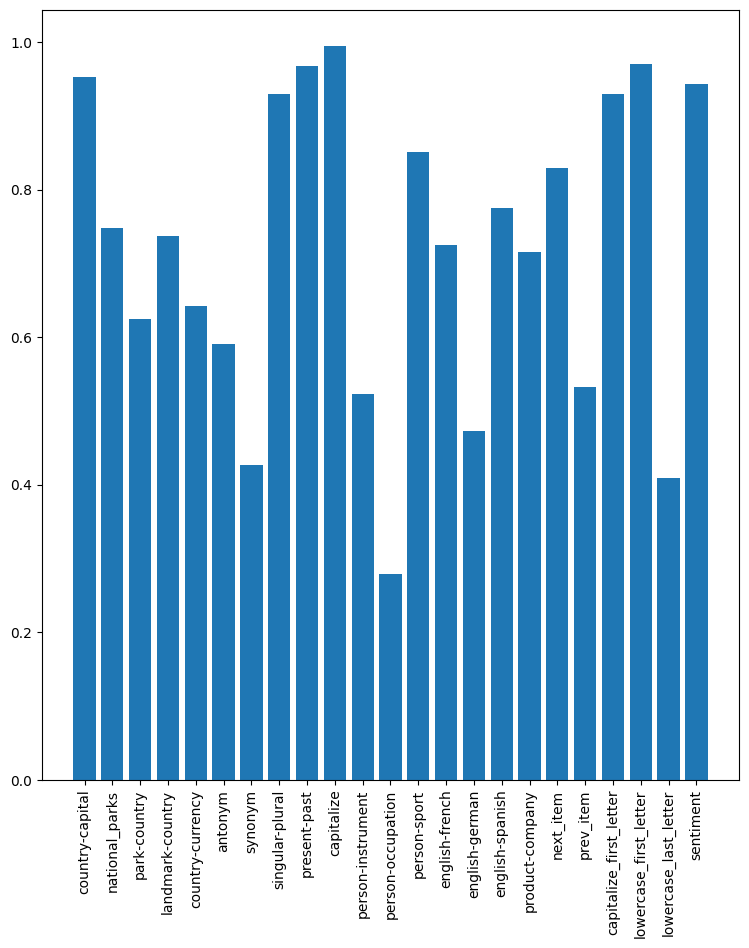

Poor Performance Subset:
 ['person-instrument', 'person-occupation', 'lowercase_last_letter']


In [49]:
poor_model_performance_subset = plot_acc_across_datasets(
    datasets=dataset_all, INST_or_ICL=INST_or_ICL,
    result_folder=result_folder, model_results_path=model_results_path)

# Top heads of each datasets

/tmp/ipykernel_2835630/2931534010.py:24: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



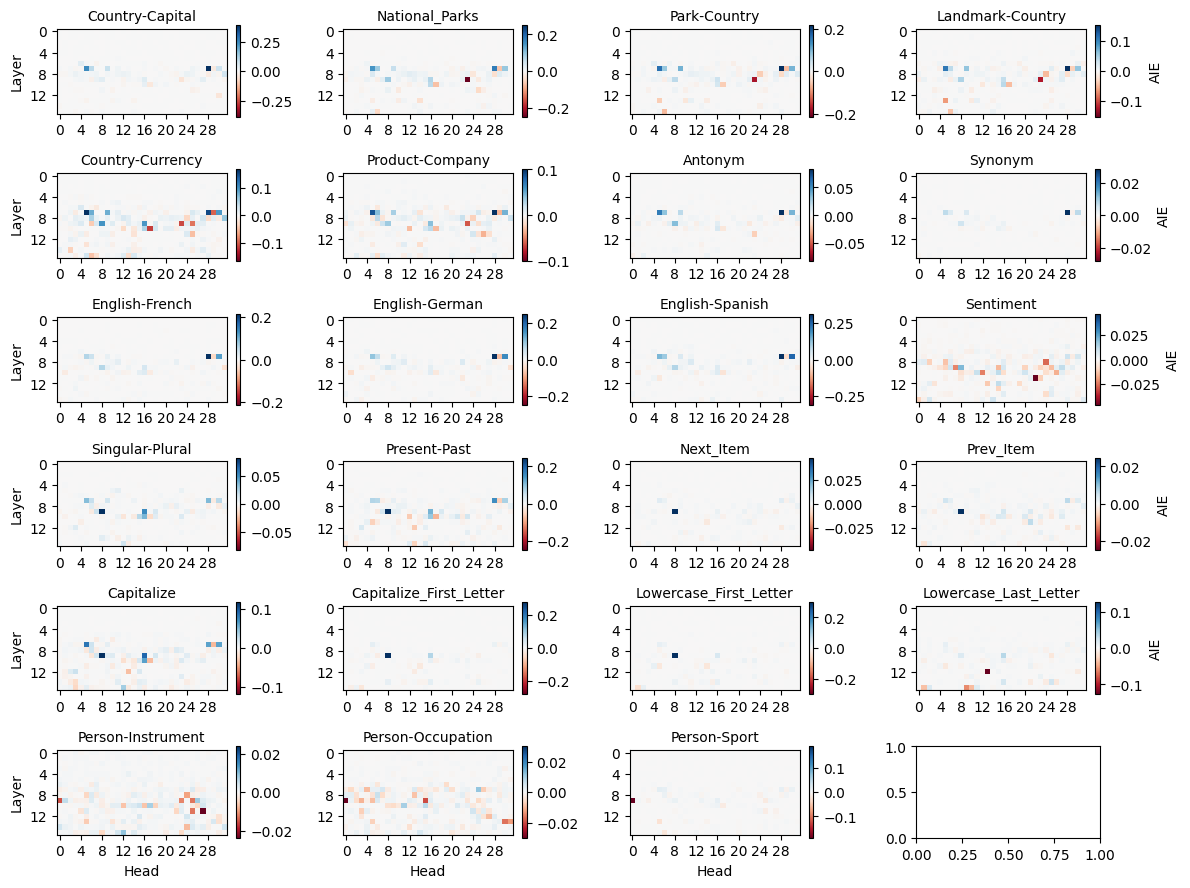

In [102]:
plot_top_heads_each_dataset(datasets=dataset_all, result_folder=result_folder, model_results_path=model_results_path,
                            custom_xticks=np.arange(0, 32, 4), custom_yticks=np.arange(0, 16, 4))

In [68]:
find_save_top_heads_per_task(datasets=dataset_all, result_folder=result_folder, 
    model_results_path=model_results_path,
    include_revision=include_revision, revision=revision)

/tmp/ipykernel_2835630/633071854.py:22: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



# Intervention acc task-specific heads 

## mean

In [ ]:

inst_intervention_mean_acc_layer_sweep_across_datasets(results_dir=result_path,
    datasets=dataset_all,
    top_k=0, universal_set=False, 
)

## each task

In [70]:
for d_name in dataset_all:
    result_path = os.path.join(result_folder,
        model_results_path, d_name)
    inst_intervention_acc_layer_sweep(results_dir=result_path, 
        universal_set=False, top_k=0, d_name=d_name)

/oscar/data/epavlick/zyang220/results/function_vector/Llama-3.2-1B-Instruct/country-capital/zs_results_layer_sweep.json


/oscar/data/epavlick/zyang220/results/function_vector/Llama-3.2-1B-Instruct/national_parks/zs_results_layer_sweep.json


/oscar/data/epavlick/zyang220/results/function_vector/Llama-3.2-1B-Instruct/park-country/zs_results_layer_sweep.json


/oscar/data/epavlick/zyang220/results/function_vector/Llama-3.2-1B-Instruct/landmark-country/zs_results_layer_sweep.json


/oscar/data/epavlick/zyang220/results/function_vector/Llama-3.2-1B-Instruct/country-currency/zs_results_layer_sweep.json


...

/oscar/data/epavlick/zyang220/results/function_vector/Llama-3.2-1B-Instruct/prev_item/zs_results_layer_sweep.json


/oscar/data/epavlick/zyang220/results/function_vector/Llama-3.2-1B-Instruct/capitalize_first_letter/zs_results_layer_sweep.json


/oscar/data/epavlick/zyang220/results/function_vector/Llama-3.2-1B-Instruct/lowercase_first_letter/zs_results_layer_sweep.json


/oscar/data/epavlick/zyang220/results/function_vector/Llama-3.2-1B-Instruct/lowercase_last_letter/zs_results_layer_sweep.json


/oscar/data/epavlick/zyang220/results/function_vector/Llama-3.2-1B-Instruct/sentiment/zs_results_layer_sweep.json


In [ ]:
for d_name in datasets:
    result_path = os.path.join(result_folder,
        model_results_path, d_name)
    inst_intervention_acc_layer_sweep(results_dir=result_path, 
        universal_set=False, top_k=1)

# universal heads 

In [104]:
AIE_across_datasets = find_save_universal_heads_across_datasets(
    datasets=dataset_for_universal_head, poor_model_performance_subset=None, 
    result_folder=result_folder, 
    model_results_path=model_results_path,
    include_revision=include_revision, revision=revision,)
# NOTE: use self-defined list of datasets, no need to exclude poor performing datasets

used datasets:  ['country-capital', 'national_parks', 'park-country', 'landmark-country', 'country-currency', 'product-company', 'antonym', 'synonym', 'english-french', 'english-german', 'english-spanish', 'singular-plural', 'present-past', 'next_item', 'prev_item', 'capitalize', 'capitalize_first_letter', 'lowercase_first_letter']
num of datasets:  18


/tmp/ipykernel_2835630/3223086715.py:20: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



Saved to None/None


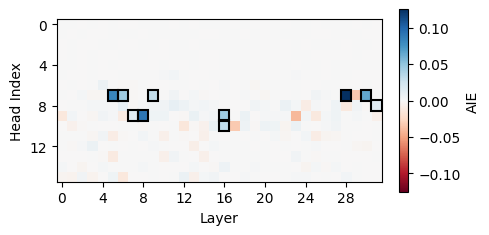

In [91]:
plot_uni_heads_across_datasets(
    AIE_across_datasets=AIE_across_datasets, 
    n_heads=n_heads, figsize=(5,4), 
    custom_xticks=np.arange(0, 32, 4), custom_yticks=np.arange(0, 16, 4),
    #save_path="/oscar/data/epavlick/zyang220/results/fv_comm/plots/Llama-3.1-8B-Instruct/fv/",
    #save_name="AIE_heatmap_INST_default_scale.pdf"
    )

## hitstogram of fv scores

In [ ]:
get_plot_AIE_histogram(
    fv_score_path='/oscar/data/epavlick/zyang220/results/function_vector_instructions/fv_scores/',
    save_path=None,
    save_name=None,
    bin_color='#2066a8', edge_color='#008dff',
    #x_ticks=np.linspace(-0.02, 0.13, 10),
    )

In [ ]:
get_plot_AIE_histogram(
    fv_score_path='/oscar/data/epavlick/zyang220/results/function_vector_instructions/fv_scores/',
    save_path=None,
    save_name=None,
    bin_color='#2066a8', edge_color='#008dff',
    x_ticks=np.linspace(-0.02, 0.13, 10),
    bin_labels=False,
    )

In [ ]:
def get_plot_AIE_histogram(
    fv_score_path=None,
    save_path=None,
    save_name=None,
    bin_color='#2066a8', edge_color='#008dff',
    x_ticks=None, bin_labels=True):    
    # Load main text file 
    txt_path = os.path.join(fv_score_path,
        f'{model_results_path}_fv_scores.txt')
    with open(txt_path, 'r') as f:
        raw = f.read()
    # a list with a string element, convert that string to a list
    head_score_list = ast.literal_eval(raw) # list of tuples: (head_index, layer_index, AIE)

    # compile the AIE to a list from head_score_list
    AIE_list = [x[2] for x in head_score_list]

    counts, bins = np.histogram(AIE_list, bins=20)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bar_width = bins[1] - bins[0]

    # Determine the max heights for adjusting axis limits dynamically
    top_counts = [c for c in counts if c > 20]  # Outliers that go to top subplot
    bottom_counts = [c for c in counts if c <= 20]

    # Create two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 5), gridspec_kw={'height_ratios': [1, 3]})

    # Plot histograms
    bars1 = ax1.bar(bin_centers, counts, width=bar_width, color=bin_color, edgecolor=edge_color)
    bars2 = ax2.bar(bin_centers, counts, width=bar_width, color=bin_color, edgecolor=edge_color)

    # Annotate bars with frequency counts inside the bars
    if bin_labels:
        for bar in bars1:
            height = bar.get_height()
            if height > 20:
                ax1.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', 
                        ha='center', va='bottom', fontsize=8)

        for bar in bars2:
            height = bar.get_height()
            if height > 0 and height <= 20:
                ax2.text(bar.get_x() + bar.get_width()/2., height+0.5, f'{int(height)}',
                        ha='center', va='bottom', fontsize=8)

    # Set y-limits dynamically to remove excess whitespace
    ax1.set_ylim(min(top_counts) - 1, max(top_counts) + 1)
    ax2.set_ylim(0, max(bottom_counts) + 3)

    # Hide the spines between ax1 and ax2
    ax1.spines['bottom'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax1.tick_params(labeltop=False, length=0)  # Remove ticks for ax1
    ax2.xaxis.tick_bottom()

    # remove some spines
    for ax in [ax1, ax2]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Add diagonal lines to indicate the break
    d = .015
    kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
    ax1.plot((-d, +d), (-d, +d), **kwargs)
    ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)

    kwargs.update(transform=ax2.transAxes)
    ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
    ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

    # Customize x-ticks for ax2
    if x_ticks is None:
        x_ticks = np.linspace(min(bins), max(bins), 10)
    ax2.set_xticks(x_ticks)
    ax2.set_xticklabels([f'{x:.2f}' for x in x_ticks])

    plt.xlabel("AIE")
    plt.ylabel("Count")
    plt.subplots_adjust(hspace=0.05)
   

    if save_path is not None:
        if not os.path.exists(save_path):
            os.makedirs(save_path)
        plt.savefig(os.path.join(save_path, save_name), format='pdf')
        plt.close()
    
    plt.show()


# Intervention acc uni heads

## mean 

In [106]:
result_path = os.path.join(result_folder,
        model_results_path)
inst_intervention_mean_acc_layer_sweep_across_datasets(results_dir=result_path,
    datasets=dataset_for_universal_head,
    top_k=0, universal_set=True, 
)

In [93]:
result_path = os.path.join(result_folder,
        model_results_path)
inst_intervention_mean_acc_layer_sweep_across_datasets(results_dir=result_path,
    datasets=dataset_all,
    top_k=0, universal_set=True, 
)

## each task 

In [105]:
for d_name in dataset_all:
    result_path = os.path.join(result_folder,
        model_results_path, d_name)
    inst_intervention_acc_layer_sweep(results_dir=result_path, 
        universal_set=True, top_k=0)

/oscar/data/epavlick/zyang220/results/function_vector/Llama-3.2-1B-Instruct/country-capital/zs_results_layer_sweep_uni_heads.json


/oscar/data/epavlick/zyang220/results/function_vector/Llama-3.2-1B-Instruct/national_parks/zs_results_layer_sweep_uni_heads.json


/oscar/data/epavlick/zyang220/results/function_vector/Llama-3.2-1B-Instruct/park-country/zs_results_layer_sweep_uni_heads.json


/oscar/data/epavlick/zyang220/results/function_vector/Llama-3.2-1B-Instruct/landmark-country/zs_results_layer_sweep_uni_heads.json


/oscar/data/epavlick/zyang220/results/function_vector/Llama-3.2-1B-Instruct/country-currency/zs_results_layer_sweep_uni_heads.json


...

/oscar/data/epavlick/zyang220/results/function_vector/Llama-3.2-1B-Instruct/lowercase_first_letter/zs_results_layer_sweep_uni_heads.json


/oscar/data/epavlick/zyang220/results/function_vector/Llama-3.2-1B-Instruct/lowercase_last_letter/zs_results_layer_sweep_uni_heads.json


/oscar/data/epavlick/zyang220/results/function_vector/Llama-3.2-1B-Instruct/person-instrument/zs_results_layer_sweep_uni_heads.json


/oscar/data/epavlick/zyang220/results/function_vector/Llama-3.2-1B-Instruct/person-occupation/zs_results_layer_sweep_uni_heads.json


/oscar/data/epavlick/zyang220/results/function_vector/Llama-3.2-1B-Instruct/person-sport/zs_results_layer_sweep_uni_heads.json


#  intervention acc mean across datasets specific heads?

In [ ]:
result_path = os.path.join(result_folder,
    model_results_path)
inst_intervention_mean_acc_layer_sweep_across_datasets(results_dir=result_path, 
    universal_set=False, top_k=1, datasets=datasets)